# Is Batting Average Overrated?

#### Gabriel DeSouza, June 2026

This is the jupyter notebook section for the end-to-end data analysis project that answers the question: Is Batting Average Overrated in modern professional baseball?

A formal writeup of the project can be out in the pdf file in the repository.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Teams.csv")

# Filtering to just the 'modern' seasons
df = df[df["yearID"] >= 2000]


df = df.reset_index(drop=True)

Now I can start examining and cleaning the dataset. First, I want to take a look at each of the columns and their respective data types. This will help me better understand the data I'm working with, while checking for missing values and incorrect entries.

In [13]:
# Using the .info() method to see what types of entries I'm working with
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 48 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   yearID          750 non-null    int64  
 1   lgID            750 non-null    object 
 2   teamID          750 non-null    object 
 3   franchID        750 non-null    object 
 4   divID           750 non-null    object 
 5   Rank            750 non-null    int64  
 6   G               750 non-null    int64  
 7   Ghome           750 non-null    float64
 8   W               750 non-null    int64  
 9   L               750 non-null    int64  
 10  DivWin          750 non-null    object 
 11  WCWin           750 non-null    object 
 12  LgWin           750 non-null    object 
 13  WSWin           750 non-null    object 
 14  R               750 non-null    int64  
 15  AB              750 non-null    int64  
 16  H               750 non-null    int64  
 17  2B              750 non-null    int

Now that I have a list of every column, I can decide which ones I want to analyze, and which ones aren't useful for this analysis.

In [14]:
df = df[[
    "yearID",
    "name",
    "W",
    "AB",
    "H",
    "2B",
    "3B",
    "HR",
    "BB",
    "SO",
    "SF",
    "HBP"
]]


print(df)

     yearID                  name   W    AB     H   2B  3B   HR   BB      SO  \
0      2000        Anaheim Angels  82  5628  1574  309  34  236  608  1024.0   
1      2001        Anaheim Angels  75  5551  1447  275  26  158  494  1001.0   
2      2002        Anaheim Angels  99  5678  1603  333  32  152  462   805.0   
3      2003        Anaheim Angels  77  5487  1473  276  33  150  476   838.0   
4      2004        Anaheim Angels  92  5675  1603  272  37  162  450   942.0   
..      ...                   ...  ..   ...   ...  ...  ..  ...  ...     ...   
745    2020  Washington Nationals  26  1968   519  112  12   66  192   451.0   
746    2021  Washington Nationals  65  5385  1388  272  20  182  573  1303.0   
747    2022  Washington Nationals  55  5434  1351  252  20  136  442  1221.0   
748    2023  Washington Nationals  71  5522  1401  279  26  151  423  1149.0   
749    2024  Washington Nationals  71  5374  1306  267  18  135  456  1220.0   

       SF   HBP  
0    43.0  47.0  
1  

Now I want to check for missing values.

In [15]:
df.isna().sum()

yearID    0
name      0
W         0
AB        0
H         0
2B        0
3B        0
HR        0
BB        0
SO        0
SF        0
HBP       0
dtype: int64

No missing values, so now I want to check the cleanliness and constistancy of the object columns. At this point I only have one; the name.

In [16]:
df["name"].value_counts()

name
Los Angeles Dodgers              25
Seattle Mariners                 25
Pittsburgh Pirates               25
Philadelphia Phillies            25
Oakland Athletics                25
New York Yankees                 25
New York Mets                    25
Minnesota Twins                  25
Milwaukee Brewers                25
San Francisco Giants             25
Kansas City Royals               25
Houston Astros                   25
St. Louis Cardinals              25
Texas Rangers                    25
Detroit Tigers                   25
Colorado Rockies                 25
Toronto Blue Jays                25
Cincinnati Reds                  25
Chicago White Sox                25
Chicago Cubs                     25
Boston Red Sox                   25
Baltimore Orioles                25
Atlanta Braves                   25
Arizona Diamondbacks             25
San Diego Padres                 25
Cleveland Indians                22
Washington Nationals             20
Los Angeles Angels of A

The final adjustment I want to make is to the 2020 season. For reasons that I go further in-depth on in the pdf (in short, it messes up the correlation coefficients), I will cut out the 2020 season from our df.

In [17]:
df = df[df["yearID"] != 2020]
df = df.reset_index(drop=True)
print(df["yearID"].value_counts().sort_index())

yearID
2000    30
2001    30
2002    30
2003    30
2004    30
2005    30
2006    30
2007    30
2008    30
2009    30
2010    30
2011    30
2012    30
2013    30
2014    30
2015    30
2016    30
2017    30
2018    30
2019    30
2021    30
2022    30
2023    30
2024    30
Name: count, dtype: int64


### Now that the dataset is clean, I can begin the analysis on whether or not batting average is overrated.

The Lahman Baseball Database doesnt contain stats such as AVG, OBP, etc. that I want to use for analysis. So first, I need to calculate them and add them to the df.

In [92]:
# For Batting Average:
df["AVG"] = df["H"] / df["AB"]


# For On-Base Percentage:
df["OBP"] = (
    df["H"] + df["BB"] + df["HBP"]
) / (
    df["AB"] + df["BB"] + df["HBP"] + df["SF"]
)


# For Slugging Percentage (and total bases (TB)):
df["TB"] = (df["H"] + df["2B"] + 2*df["3B"] + 3*df["HR"])
df["SLG"] = df["TB"] / df["AB"]


# For On-base plus Slugging:
df["OPS"] = df["OBP"] + df["SLG"]

# For Walk Rate:
df["PA"] = df["AB"] + df["BB"] + df["HBP"] + df["SF"]
df["%BB"] = df["BB"] / df["PA"]

# For Strikeout Rate:
df["%SO"] = df["SO"] / df["PA"]

# For Isolated Power:
df["ISO"] = df["SLG"] - df["AVG"]

df["GABE"] = df["H"] + df["2B"] + 3*df["HR"]
df["GSLG"] = df["GABE"] / df["AB"]

df["APOPS"] = df["AVG"] + df["SLG"] + df["OBP"]


print(df.head(5))

   yearID            name   W    AB     H   2B  3B   HR   BB      SO  ...  \
0    2000  Anaheim Angels  82  5628  1574  309  34  236  608  1024.0  ...   
1    2001  Anaheim Angels  75  5551  1447  275  26  158  494  1001.0  ...   
2    2002  Anaheim Angels  99  5678  1603  333  32  152  462   805.0  ...   
3    2003  Anaheim Angels  77  5487  1473  276  33  150  476   838.0  ...   
4    2004  Anaheim Angels  92  5675  1603  272  37  162  450   942.0  ...   

        SLG       OPS      PA       %BB       %SO       ISO   obp-avg  GABE  \
0  0.472459  0.824814  6326.0  0.096111  0.161872  0.192786  0.072682  2591   
1  0.404972  0.731774  6175.0  0.080000  0.162105  0.144298  0.066128  2196   
2  0.432547  0.773260  6278.0  0.073590  0.128226  0.150229  0.058396  2392   
3  0.412794  0.743161  6069.0  0.078431  0.138079  0.144341  0.061915  2199   
4  0.429075  0.769835  6239.0  0.072127  0.150986  0.146608  0.058293  2361   

       GSLG     APOPS  
0  0.460377  1.104488  
1  0.395604  0

Now that I have all the stats I want to analyze, I can calculate the Pearson Correlation coefficients between wins and the other metrics. 

In [93]:
# First I will make a df that includes only numerical entries.
numeric_df = df.select_dtypes(include="number")

# Now I can use the .corr method to calculate the pearson correlation coefficients of every combination of the numeric metrics and put it into a matrix.
corr_matrix = numeric_df.corr()

# Finally I want to print the 'W' column of this matrix to grab all the correlation coefficients with the wins column.
print(corr_matrix["W"].sort_values(ascending=False))

W          1.000000
OPS        0.548733
GSLG       0.526657
OBP        0.523684
APOPS      0.522195
SLG        0.515633
GABE       0.498934
TB         0.486556
BB         0.459078
ISO        0.452761
%BB        0.437609
PA         0.436619
HR         0.423764
obp-avg    0.377410
AVG        0.360059
H          0.333838
SF         0.294906
2B         0.267294
AB         0.181645
HBP        0.163079
yearID     0.001417
3B        -0.085006
SO        -0.120146
%SO       -0.171184
Name: W, dtype: float64


Now that we can see which stats are most highly correlated with wins, it would also be helpful to visualize them.

In [56]:
# This cell is for easily finding specific team-seasons to use as graph labels.

print(
    df[["yearID", "name", "W", "AVG"]] 
    .sort_values("AVG", ascending=False)
    .head(10)
)

     yearID                name    W       AVG
216    2000    Colorado Rockies   82  0.293993
217    2001    Colorado Rockies   73  0.292267
439    2007    New York Yankees   94  0.289662
99     2003      Boston Red Sox   95  0.288958
192    2000   Cleveland Indians   90  0.288404
553    2001    Seattle Mariners  116  0.288204
312    2000  Kansas City Royals   77  0.287966
390    2006     Minnesota Twins   96  0.287040
247    2007      Detroit Tigers   88  0.286955
559    2007    Seattle Mariners   88  0.286594


In [79]:
# Some setup code for plot labels

athletics = df[(df["yearID"] == 2002) & (df["name"] == "Oakland Athletics")]
print(athletics)

rockies = df[(df["yearID"] == 2001) & (df["name"] == "Colorado Rockies")]
print(rockies)


     yearID               name    W    AB     H   2B  3B   HR   BB      SO  \
458    2002  Oakland Athletics  103  5558  1450  279  28  205  609  1008.0   

     ...       AVG      OBP    TB      SLG      OPS      PA       %BB  \
458  ...  0.260885  0.33918  2400  0.43181  0.77099  6271.0  0.097114   

         %SO       ISO   obp-avg  
458  0.16074  0.170925  0.078295  

[1 rows x 22 columns]
     yearID              name   W    AB     H   2B  3B   HR   BB      SO  ...  \
217    2001  Colorado Rockies  73  5690  1663  324  61  213  511  1027.0  ...   

          AVG       OBP    TB       SLG      OPS      PA       %BB       %SO  \
217  0.292267  0.354087  2748  0.482953  0.83704  6312.0  0.080957  0.162706   

          ISO  obp-avg  
217  0.190685  0.06182  

[1 rows x 22 columns]


<function matplotlib.pyplot.show(close=None, block=None)>

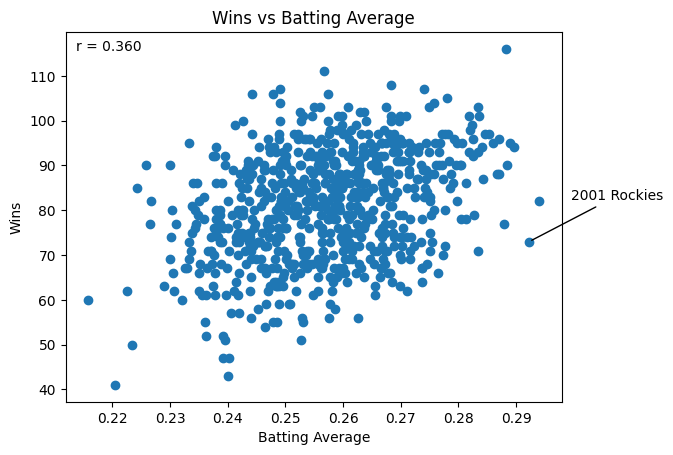

In [73]:
corr = df["AVG"].corr(df["W"])

plt.scatter(df["AVG"], df["W"])

plt.text(
    0.02,
    0.95,
    f"r = {corr:.3f}",
    transform=plt.gca().transAxes
)




plt.annotate(
    "2001 Rockies",
    xy=(rockies["AVG"].iloc[0], rockies["W"].iloc[0]),   # point being labeled
    xytext=(30, 30),                                       # move label 30 pts right, 30 pts up
    textcoords="offset points",
    arrowprops=dict(
        arrowstyle="-",
        lw=1
    )
)







plt.xlabel("Batting Average")
plt.ylabel("Wins")
plt.title("Wins vs Batting Average")


plt.savefig("wins_avg.png", dpi=300, bbox_inches="tight")

plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

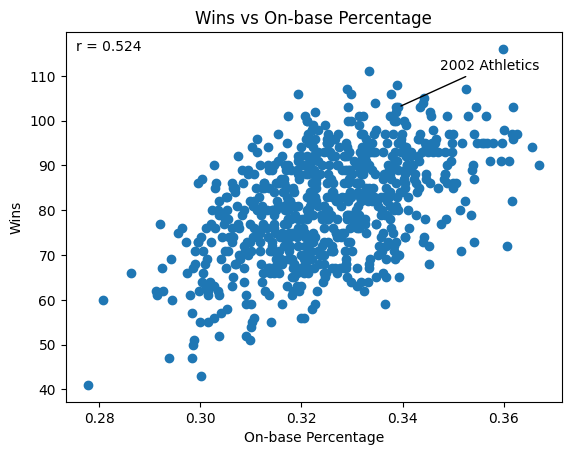

In [75]:

corr = df["OBP"].corr(df["W"])

plt.scatter(df["OBP"], df["W"])

plt.text(
    0.02,
    0.95,
    f"r = {corr:.3f}",
    transform=plt.gca().transAxes
)


plt.annotate(
    "2002 Athletics",
    xy=(athletics["OBP"].iloc[0], athletics["W"].iloc[0]),   # point being labeled
    xytext=(30, 27),                                       # move label 30 pts right, 27 pts up
    textcoords="offset points",
    arrowprops=dict(
        arrowstyle="-",
        lw=1
    )
)






plt.xlabel("On-base Percentage")
plt.ylabel("Wins")
plt.title("Wins vs On-base Percentage")


plt.savefig("wins_obp.png", dpi=300, bbox_inches="tight")

plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

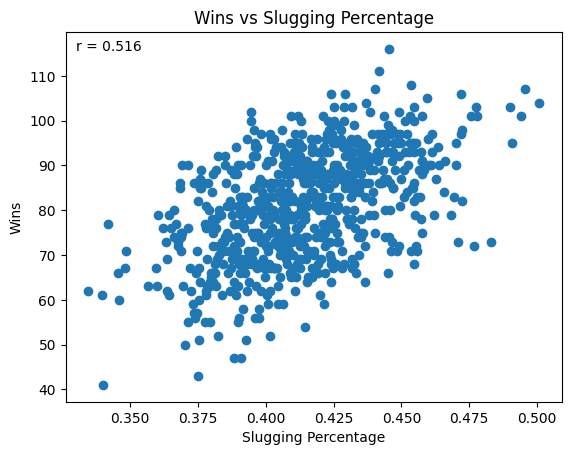

In [76]:
corr = df["SLG"].corr(df["W"])

plt.scatter(df["SLG"], df["W"])

plt.text(
    0.02,
    0.95,
    f"r = {corr:.3f}",
    transform=plt.gca().transAxes
)



plt.xlabel("Slugging Percentage")
plt.ylabel("Wins")
plt.title("Wins vs Slugging Percentage")


plt.savefig("wins_slg.png", dpi=300, bbox_inches="tight")

plt.show




<function matplotlib.pyplot.show(close=None, block=None)>

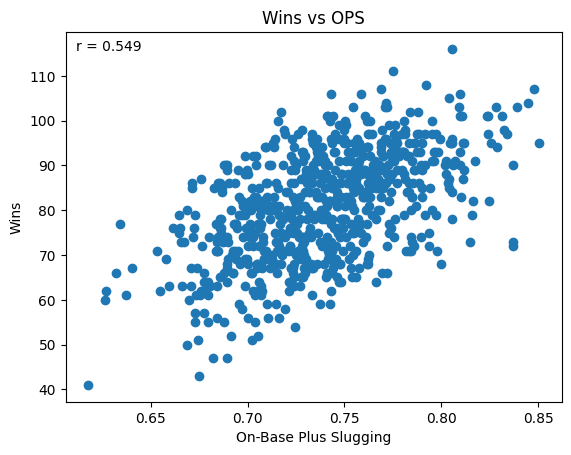

In [78]:
corr = df["OPS"].corr(df["W"])

plt.scatter(df["OPS"], df["W"])

plt.text(
    0.02,
    0.95,
    f"r = {corr:.3f}",
    transform=plt.gca().transAxes
)



plt.xlabel("On-Base Plus Slugging")
plt.ylabel("Wins")
plt.title("Wins vs OPS")


plt.savefig("wins_ops.png", dpi=300, bbox_inches="tight")

plt.show


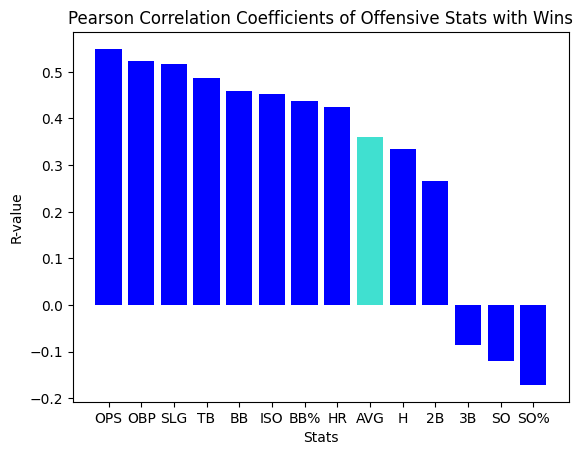

In [108]:


stats = ["OPS", "OBP", "SLG", "TB", "BB", "ISO", "BB%", "HR", "AVG", "H", "2B", "3B", "SO", "SO%"]
r_values = [0.549, 0.524, 0.516, 0.487, 0.459, 0.453, 0.438, 0.424, 0.360, 0.334, 0.267, -0.085, -0.120, -0.171]
colors = ["blue", "blue", "blue", "blue", "blue", "blue", "blue", "blue", "turquoise", "blue", "blue", "blue", "blue", "blue"]

plt.bar(stats, r_values, color = colors)


plt.xlabel("Stats")
plt.ylabel("R-value")
plt.title("Pearson Correlation Coefficients of Offensive Stats with Wins")

plt.savefig("rvalue_avg.png", dpi=300, bbox_inches="tight")


plt.show()